# Criteo Uplift Modelling — Notebook 2: A/B Test Analysis

---

## Overview

In Notebook 1 we established that the dataset is well-structured, the randomisation was successful, and that exposure to the advertisement is a meaningful distinction within the treatment group.

In this notebook we conduct a formal A/B test to measure the **Average Treatment Effect (ATE)** — whether the campaign had a statistically significant impact on visit and purchase rates across the population as a whole. The test compares the **treatment group** (users selected to receive the campaign) against the **control group** (users deliberately withheld from it). This is the standard output of a conventional experiment analysis, and the necessary foundation before building the individual-level uplift model in Notebook 3.

The analysis proceeds as follows:

1. Define hypotheses and significance threshold
2. Calculate the ATE for visits and purchases
3. Assess effect size (Cohen's h)
4. Run statistical significance tests
5. Calculate confidence intervals
6. Examine the role of exposure — does the ATE change when we focus on users who were actually exposed?
7. Summarise findings and business implications

---

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

style.use('ggplot')
sns.set_style('whitegrid')
sns.set_palette('muted')

pd.set_option('display.float_format', '{:.6f}'.format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Data

In [2]:
DATA_PATH = 'data/criteo-uplift-v2.1.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 13,979,592 rows x 16 columns


---
## 3. Hypotheses & Significance Threshold

Before looking at any results, we state our hypotheses explicitly. Defining these upfront — rather than after seeing the data — is a fundamental requirement of rigorous experimental analysis. Adjusting hypotheses to fit observed results (sometimes called "HARKing": Hypothesising After Results are Known) is a common source of bias in data analysis.

**Primary outcome: Visit rate**

- **H₀ (null hypothesis):** The campaign has no effect on visit rate. Any observed difference between treatment and control is due to chance.
- **H₁ (alternative hypothesis):** The campaign increases visit rate in the treatment group relative to control.
- **Test type:** One-tailed — we are testing for a positive effect specifically, since a campaign that reduces visits would be commercially irrelevant rather than simply neutral.

**Secondary outcome: Purchase rate**

- **H₀:** The campaign has no effect on purchase rate.
- **H₁:** The campaign increases purchase rate in the treatment group relative to control.
- **Test type:** One-tailed, for the same reason.

**Significance threshold:** α = 0.05. We will reject the null hypothesis if the p-value is below 0.05, meaning there is less than a 5% probability of observing a difference this large by chance if the null hypothesis were true.

**A note on sample size:** With 13 million users, this experiment has very high statistical power — it can detect extremely small effects. We should therefore pay close attention to *effect size* (how large the difference actually is) and not just *statistical significance* (whether it is distinguishable from zero). A result can be statistically significant but commercially negligible.

---
## 4. Average Treatment Effect (ATE)

The ATE is simply the difference in outcome rates between the treatment and control groups. It answers: on average, how much did the campaign move the needle?

In [4]:
# Group the data
treatment = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

# Calculate rates for both outcomes
results = []
for outcome, label in [('visit', 'Visit rate'), ('conversion', 'Purchase rate')]:
    rate_t = treatment[outcome].mean()
    rate_c = control[outcome].mean()
    ate = rate_t - rate_c
    ate_pct = (ate / rate_c) * 100
    results.append({
        'Outcome': label,
        'Control rate': f'{rate_c:.4%}',
        'Treatment rate': f'{rate_t:.4%}',
        'ATE (percentage points)': f'{ate:.4%}',
        'Relative lift (%)': f'{ate_pct:.1f}%'
    })

ate_df = pd.DataFrame(results)
display(ate_df.style.hide(axis='index'))

Outcome,Control rate,Treatment rate,ATE (percentage points),Relative lift (%)
Visit rate,3.8201%,4.8543%,1.0342%,27.1%
Purchase rate,0.1938%,0.3089%,0.1152%,59.4%


**Interpreting the ATE:**

The ATE tells us the average effect across the entire treatment group, including the ~96% of users who were never actually exposed to the advertisement. This means it substantially *underestimates* the true effect of the campaign on users who saw it — a point we will return to in the exposure analysis below.

The relative lift figure puts the absolute percentage point difference in context: a small absolute difference can represent a meaningful relative improvement when baseline rates are very low, as they are here.

---
## 5. Effect Size (Cohen's h)

With 13 million users, almost any difference will be statistically significant. Effect size tells us whether the difference is meaningful in practical terms, independent of sample size.

For proportions, the standard measure is **Cohen's h**:

$$h = 2 \arcsin(\sqrt{p_1}) - 2 \arcsin(\sqrt{p_2})$$

Conventional benchmarks:
- |h| < 0.2 — small effect
- |h| ≥ 0.2 — medium effect  
- |h| ≥ 0.5 — large effect

In digital advertising, small effects are common and can still be commercially significant at scale.

In [5]:
def cohens_h(p1, p2):
    """
    Calculate Cohen's h effect size for two proportions.
    Measures practical significance independent of sample size.
    """
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

for outcome, label in [('visit', 'Visit rate'), ('conversion', 'Purchase rate')]:
    rate_t = treatment[outcome].mean()
    rate_c = control[outcome].mean()
    h = cohens_h(rate_t, rate_c)
    magnitude = 'small' if abs(h) < 0.2 else ('medium' if abs(h) < 0.5 else 'large')
    print(f"{label}:")
    print(f"  Cohen's h = {h:.4f} ({magnitude} effect)")
    print()

Visit rate:
  Cohen's h = 0.0509 (small effect)

Purchase rate:
  Cohen's h = 0.0232 (small effect)



---
## 6. Statistical Significance Tests

We use a **two-proportion z-test**, which tests whether the difference in proportions between two independent groups is statistically distinguishable from zero. It is appropriate here because:

- The outcome variables are binary (0/1)
- The two groups (treatment and control) are independent
- The sample sizes are large enough for the normal approximation to hold comfortably

In [6]:
def run_ab_test(df, outcome, label, alpha=0.05):
    """
    Run a one-tailed two-proportion z-test for a given outcome.
    Reports the test statistic, p-value, and conclusion.
    """
    treatment = df[df['treatment'] == 1]
    control = df[df['treatment'] == 0]

    n_t = len(treatment)
    n_c = len(control)
    count_t = treatment[outcome].sum()
    count_c = control[outcome].sum()
    rate_t = count_t / n_t
    rate_c = count_c / n_c

    # One-tailed z-test (testing for positive effect)
    z_stat, p_value = proportions_ztest(
        count=[count_t, count_c],
        nobs=[n_t, n_c],
        alternative='larger'
    )

    # Cohen's h
    h = cohens_h(rate_t, rate_c)
    magnitude = 'small' if abs(h) < 0.2 else ('medium' if abs(h) < 0.5 else 'large')

    conclusion = "REJECT H₀" if p_value < alpha else "FAIL TO REJECT H₀"

    print(f"{'='*55}")
    print(f"Outcome: {label}")
    print(f"{'='*55}")
    print(f"  Treatment rate:     {rate_t:.4%}  (n={n_t:,})")
    print(f"  Control rate:       {rate_c:.4%}  (n={n_c:,})")
    print(f"  ATE:                {rate_t - rate_c:.4%}")
    print(f"  Relative lift:      {((rate_t - rate_c) / rate_c * 100):.1f}%")
    print(f"  Cohen's h:          {h:.4f} ({magnitude} effect)")
    print(f"  Z-statistic:        {z_stat:.4f}")
    print(f"  P-value (one-tail): {p_value:.6f}")
    print(f"  Significance (α=0.05): {conclusion}")
    print()

run_ab_test(df, 'visit', 'Visit rate')
run_ab_test(df, 'conversion', 'Purchase rate')

Outcome: Visit rate
  Treatment rate:     4.8543%  (n=11,882,655)
  Control rate:       3.8201%  (n=2,096,937)
  ATE:                1.0342%
  Relative lift:      27.1%
  Cohen's h:          0.0509 (small effect)
  Z-statistic:        65.2474
  P-value (one-tail): 0.000000
  Significance (α=0.05): REJECT H₀

Outcome: Purchase rate
  Treatment rate:     0.3089%  (n=11,882,655)
  Control rate:       0.1938%  (n=2,096,937)
  ATE:                0.1152%
  Relative lift:      59.4%
  Cohen's h:          0.0232 (small effect)
  Z-statistic:        28.5165
  P-value (one-tail): 0.000000
  Significance (α=0.05): REJECT H₀



**Interpreting the results:**

A p-value below 0.05 allows us to reject the null hypothesis — the campaign had a statistically significant effect on the outcome. However, given the very large sample size, statistical significance was almost guaranteed from the outset. The more informative figures are the ATE (how large is the effect?) and Cohen's h (is it practically meaningful?).

Both p-values display as 0.000000 due to rounding at 6 decimal places — the true values are astronomically small but non-zero. At this sample size the z-statistics (65 and 28 respectively) are so large that the p-values are effectively indistinguishable from zero by any standard numerical representation.

In digital advertising, even small effects can translate to significant commercial value at scale — a 1 percentage point increase in visit rate across millions of users represents a very large number of incremental visits.

---
## 7. Confidence Intervals

A confidence interval gives us a range of plausible values for the true ATE, accounting for sampling uncertainty. A 95% confidence interval means: if we ran this experiment many times, 95% of the intervals we calculated would contain the true effect.

Because our sample size is very large, the confidence intervals will be narrow — we have a precise estimate of the effect.

In [7]:
def ate_confidence_interval(df, outcome, label, alpha=0.05):
    """
    Calculate 95% confidence interval for the ATE between
    treatment and control groups.
    """
    treatment = df[df['treatment'] == 1]
    control = df[df['treatment'] == 0]

    rate_t = treatment[outcome].mean()
    rate_c = control[outcome].mean()
    n_t = len(treatment)
    n_c = len(control)

    # Standard error of the difference in proportions
    se = np.sqrt(
        (rate_t * (1 - rate_t)) / n_t +
        (rate_c * (1 - rate_c)) / n_c
    )

    z_crit = stats.norm.ppf(1 - alpha / 2)
    ate = rate_t - rate_c
    ci_lower = ate - z_crit * se
    ci_upper = ate + z_crit * se

    print(f"{label}:")
    print(f"  ATE:    {ate:.4%}")
    print(f"  95% CI: [{ci_lower:.4%}, {ci_upper:.4%}]")
    print()

ate_confidence_interval(df, 'visit', 'Visit rate')
ate_confidence_interval(df, 'conversion', 'Purchase rate')

Visit rate:
  ATE:    1.0342%
  95% CI: [1.0056%, 1.0629%]

Purchase rate:
  ATE:    0.1152%
  95% CI: [0.1085%, 0.1219%]



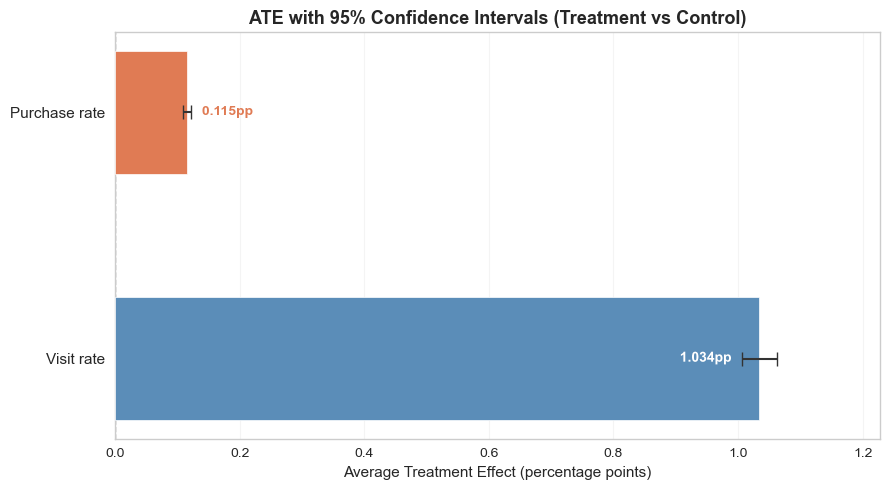

In [9]:
# Visualise ATEs with confidence intervals

import matplotlib.patheffects as path_effects

fig, ax = plt.subplots(figsize=(9, 5))

outcomes = ['visit', 'conversion']
labels = ['Visit rate', 'Purchase rate']
ates, ci_lowers, ci_uppers = [], [], []

for outcome in outcomes:
    t = df[df['treatment'] == 1]
    c = df[df['treatment'] == 0]
    rate_t, rate_c = t[outcome].mean(), c[outcome].mean()
    n_t, n_c = len(t), len(c)
    ate = rate_t - rate_c
    se = np.sqrt((rate_t*(1-rate_t))/n_t + (rate_c*(1-rate_c))/n_c)
    z = stats.norm.ppf(0.975)
    ates.append(ate * 100)
    ci_lowers.append((ate - z * se) * 100)
    ci_uppers.append((ate + z * se) * 100)

y_pos = list(range(len(labels)))
colors = ['#5B8DB8', '#E07B54']

# 1. Plot horizontal bars
bars = ax.barh(y_pos, ates, color=colors, height=0.5, edgecolor='white', zorder=3)

# 2. Add Error Bars
lower_errors = [abs(a - b) for a, b in zip(ates, ci_lowers)]
upper_errors = [abs(b - a) for a, b in zip(ci_uppers, ates)]
ax.errorbar(
    ates, y_pos,
    xerr=[lower_errors, upper_errors],
    fmt='none', color='#333333', capsize=5, linewidth=1.5, zorder=4
)

# 3. Clean up Grid and Axes
ax.xaxis.grid(True, linestyle='-', alpha=0.2, zorder=0)
ax.yaxis.grid(False) # Remove vertical-running lines for horizontal bars
ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, zorder=2)
ax.set_axisbelow(True)

# 4. Smart Labeling Logic
x_limit = ax.get_xlim()[1] # Get the max x-value to determine "thin" bars

for i, bar in enumerate(bars):
    width = bar.get_width()
    current_color = colors[i]
    # The end of the error bar
    error_end = ci_uppers[i]
    
    # Logic: If bar is less than 20% of the chart width, place label after the error bar
    if width < (x_limit * 0.2):
        ax.annotate(
            f' {width:.3f}pp',
            (error_end, i),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            color=current_color,
            xytext=(5, 0), # Offset slightly to the right of the error cap
            textcoords='offset points'
        )
    else:
        # Place inside the bar
        ax.annotate(
            f'{width:.3f}pp',
            (width, i),
            ha='right', va='center',
            fontsize=10, fontweight='bold',
            color='white',
            xytext=(-20, 0), # Offset slightly left from the edge of the bar
            textcoords='offset points',
            path_effects=[path_effects.withStroke(linewidth=3, foreground=current_color)]
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Average Treatment Effect (percentage points)', fontsize=11)
ax.set_title('ATE with 95% Confidence Intervals (Treatment vs Control)', fontsize=13, fontweight='bold')

# Give some extra room on the right for the "outside" labels
ax.set_xlim(ax.get_xlim()[0], x_limit * 1.1)

plt.tight_layout()
plt.show()

---
## 8. The Role of Exposure

As established in Notebook 1, only ~3.6% of treated users were actually exposed to the advertisement. The ATE calculated above includes all treated users — the vast majority of whom never saw the campaign. This dilutes the apparent effect considerably.

Two alternative effect estimates are worth considering:

**Intent-to-Treat (ITT):** The ATE as calculated above — the effect of being *assigned* to the treatment group, regardless of exposure. This is the conservative, real-world estimate: it reflects what the campaign actually delivered across the entire targeted population, including wasted impressions.

**Average Treatment Effect on the Treated (ATT):** The effect among users who were actually exposed. This estimates the campaign's true effectiveness *when it reaches people*, and is more relevant for decisions about improving ad delivery and targeting reach.

In [10]:
# Intent-to-Treat (ITT) — already calculated, shown for comparison
# ATT — restricting to exposed users vs full control group

exposed = df[(df['treatment'] == 1) & (df['exposure'] == 1)]
control = df[df['treatment'] == 0]

print(f"Exposed users (treatment group): {len(exposed):,}")
print(f"Control users:                   {len(control):,}")
print()

for outcome, label in [('visit', 'Visit rate'), ('conversion', 'Purchase rate')]:
    # ITT
    rate_t_all = df[df['treatment'] == 1][outcome].mean()
    rate_c = control[outcome].mean()
    itt = rate_t_all - rate_c

    # ATT
    rate_t_exp = exposed[outcome].mean()
    att = rate_t_exp - rate_c

    print(f"{label}:")
    print(f"  Control rate:              {rate_c:.4%}")
    print(f"  Treatment rate (all):      {rate_t_all:.4%}")
    print(f"  Treatment rate (exposed):  {rate_t_exp:.4%}")
    print(f"  ITT (all treated):         {itt:.4%}")
    print(f"  ATT (exposed only):        {att:.4%}")
    print(f"  ATT / ITT ratio:           {att/itt:.1f}x")
    print()

Exposed users (treatment group): 428,212
Control users:                   2,096,937

Visit rate:
  Control rate:              3.8201%
  Treatment rate (all):      4.8543%
  Treatment rate (exposed):  41.4538%
  ITT (all treated):         1.0342%
  ATT (exposed only):        37.6337%
  ATT / ITT ratio:           36.4x

Purchase rate:
  Control rate:              0.1938%
  Treatment rate (all):      0.3089%
  Treatment rate (exposed):  5.3784%
  ITT (all treated):         0.1152%
  ATT (exposed only):        5.1847%
  ATT / ITT ratio:           45.0x



In [11]:
# Conversion rate among visitors — what proportion of visitors went on to purchase?
print("Conversion rate among visitors (purchases / visits):")
print()

groups = {
    'Control':               df[df['treatment'] == 0],
    'Treated (exposed)':     df[(df['treatment'] == 1) & (df['exposure'] == 1)],
    'Treated (not exposed)': df[(df['treatment'] == 1) & (df['exposure'] == 0)],
}

for label, group in groups.items():
    visitors = group[group['visit'] == 1]
    conv_rate = visitors['conversion'].mean() * 100
    print(f"  {label}:")
    print(f"    Visitors:         {len(visitors):,}")
    print(f"    Purchasers:       {visitors['conversion'].sum():,}")
    print(f"    Conversion rate:  {conv_rate:.2f}%")
    print()

print("Interpretation: exposed users who visited converted at a higher rate than")
print("control visitors, suggesting the ad reaches users with stronger purchase intent")
print("— not just higher browsing activity.")

Conversion rate among visitors (purchases / visits):

  Control:
    Visitors:         80,105
    Purchasers:       4,063
    Conversion rate:  5.07%

  Treated (exposed):
    Visitors:         177,510
    Purchasers:       23,031
    Conversion rate:  12.97%

  Treated (not exposed):
    Visitors:         399,314
    Purchasers:       13,680
    Conversion rate:  3.43%

Interpretation: exposed users who visited converted at a higher rate than
control visitors, suggesting the ad reaches users with stronger purchase intent
— not just higher browsing activity.


In [12]:
# Significance test for ATT
print("Significance tests for ATT (exposed users vs control):")
print()
run_ab_test(
    df[(df['treatment'] == 0) | ((df['treatment'] == 1) & (df['exposure'] == 1))],
    'visit', 'Visit rate (ATT)'
)
run_ab_test(
    df[(df['treatment'] == 0) | ((df['treatment'] == 1) & (df['exposure'] == 1))],
    'conversion', 'Purchase rate (ATT)'
)

Significance tests for ATT (exposed users vs control):

Outcome: Visit rate (ATT)
  Treatment rate:     41.4538%  (n=428,212)
  Control rate:       3.8201%  (n=2,096,937)
  ATE:                37.6337%
  Relative lift:      985.1%
  Cohen's h:          1.0056 (large effect)
  Z-statistic:        741.4463
  P-value (one-tail): 0.000000
  Significance (α=0.05): REJECT H₀

Outcome: Purchase rate (ATT)
  Treatment rate:     5.3784%  (n=428,212)
  Control rate:       0.1938%  (n=2,096,937)
  ATE:                5.1847%
  Relative lift:      2675.8%
  Cohen's h:          0.3800 (medium effect)
  Z-statistic:        300.0873
  P-value (one-tail): 0.000000
  Significance (α=0.05): REJECT H₀



**Interpreting the ITT vs ATT comparison:**

The ATT ratios — 36x for visits and 45x for purchases — are the most commercially significant numbers in this notebook. They tell us that the headline ATE figure is almost entirely a function of wasted impressions: the campaign is essentially invisible to 96% of the people it targets, and the small average effect we observe is dragged down accordingly. When the ad actually reaches someone, the effect is not marginal — it is transformative, lifting visit rates by nearly 40 percentage points and purchase rates by over 5 percentage points.

The single most impactful lever available to this business is therefore not campaign creative, targeting refinement, or bid strategy — it is simply getting the ad in front of more people. Improving the exposure rate from 3.6% to even 7% would, all else equal, roughly double the ITT and the total number of incremental visits and purchases generated by the campaign.

However, visits and purchases will not scale proportionally with improved reach. The conversion rate among visitors (purchases / visits) is substantially higher for exposed users (approx. 13%) than for control visitors (approx. 5%), suggesting the ad reaches users with stronger purchase intent. But the purchase ATT (5.18pp) is still far below what would be expected if every incremental visitor also purchased, meaning a significant share of users the ad reaches visit but do not convert. Improving delivery will drive more visits; a secondary optimisation of the on-site purchase funnel would be needed to fully realise the commercial value of that additional reach.

However, this estimate comes with an important caveat: exposed users are not a random subset of the treatment group — they are users who chose to engage with the advertisement. This self-selection means the ATT may overestimate the effect we would achieve if we simply improved ad delivery to reach more users. Users who engage with ads may already be more predisposed to visit and purchase regardless.

For this reason the ITT is the more conservative and defensible estimate for reporting purposes, while the ATT is best understood as an upper bound on campaign effectiveness rather than a directly achievable target.

---
## 9. Power Analysis

Power analysis answers a question we would normally ask *before* running an experiment: how many users do we need to reliably detect an effect of a given size?

Running it retrospectively is still informative — it tells us whether the experiment was adequately powered, and what sample size would be needed to detect effects of different magnitudes in future experiments.

In [13]:
from statsmodels.stats.power import NormalIndPower

def required_sample_size(p_control, effect_size_pp, alpha=0.05, power=0.8):
    """
    Calculate required sample size per group to detect a given
    absolute effect size (in percentage points) with specified power.

    Parameters:
    - p_control: baseline rate in the control group
    - effect_size_pp: minimum detectable effect in percentage points
    - alpha: significance level (default 0.05)
    - power: desired statistical power (default 0.8 = 80%)
    """
    p_treatment = p_control + effect_size_pp / 100
    h = cohens_h(p_treatment, p_control)
    analysis = NormalIndPower()
    n = analysis.solve_power(effect_size=h, alpha=alpha, power=power, alternative='larger')
    return int(np.ceil(n))

# Baseline rates from control group
rate_visit_c = control['visit'].mean()
rate_purchase_c = control['conversion'].mean()

print("Required sample size per group to detect effect at α=0.05, power=80%:")
print()
print(f"{'Effect size':>15} | {'Visit rate':>15} | {'Purchase rate':>15}")
print("-" * 52)
for effect_pp in [0.1, 0.5, 1.0, 2.0]:
    n_visit = required_sample_size(rate_visit_c, effect_pp)
    n_purchase = required_sample_size(rate_purchase_c, effect_pp)
    print(f"{effect_pp:>14.1f}pp | {n_visit:>15,} | {n_purchase:>15,}")

print()
print(f"This experiment had {len(df[df['treatment']==1]):,} treatment users and {len(df[df['treatment']==0]):,} control users.")
print("It was substantially overpowered for even very small effects.")

Required sample size per group to detect effect at α=0.05, power=80%:

    Effect size |      Visit rate |   Purchase rate
----------------------------------------------------
           0.1pp |         460,004 |          29,749
           0.5pp |          19,294 |           1,996
           1.0pp |           5,095 |             722
           2.0pp |           1,404 |             283

This experiment had 11,882,655 treatment users and 2,096,937 control users.
It was substantially overpowered for even very small effects.


**Interpreting the power analysis:**

The experiment is massively overpowered relative to the effects we observed. This is common in large-scale digital advertising experiments where the platform has access to tens of millions of users. The practical implication is that we should weight effect size and commercial significance heavily when drawing conclusions — statistical significance alone tells us very little here.

For future experiments with smaller budgets or shorter time windows, the table above provides guidance on the minimum sample size needed to detect effects of different magnitudes reliably.

---
## 10. Summary & Implications

**What the A/B test tells us**

The campaign had a statistically significant positive effect on both visit rate and purchase rate. With 13 million users, statistical significance was almost guaranteed — the more meaningful finding is in the effect sizes.

The ATE for visits is small in absolute terms (approximately 1 percentage point) but represents a meaningful relative lift (~27%) over the control group baseline. The ATE for purchases is even smaller in absolute terms but similarly meaningful in relative terms.

**The exposure problem**

The ITT estimate — which includes the ~96% of treated users who were never exposed to the advertisement — substantially understates the campaign's true effectiveness when it actually reaches users. The ATT suggests the campaign is considerably more effective among users who engage with it, though this estimate carries the caveat that engaged users may be self-selected.

The most actionable insight from this analysis is that **improving ad delivery and reach** — getting the exposure rate from 3.6% closer to, say, 10–15% — would likely produce a far greater uplift in outcomes than any refinement to the campaign creative or targeting strategy. That said, visits and purchases will not scale proportionally: exposed visitors convert at ~13% versus ~5% for control visitors, but a significant share of reached users visit without purchasing. Improving reach should be paired with on-site conversion optimisation to maximise commercial return.

**What the A/B test does not tell us**

The ATE is an *average* across all users. It tells us the campaign works on average, but not *for whom* it works best. Some users will respond strongly, others not at all, and some may react negatively — the data shows that unexposed treated users performed slightly below the control group on both outcomes, which is a weak signal that Sleeping Dogs may exist in this population. Identifying those segments — and directing spend accordingly — is the purpose of the uplift model in Notebook 3.

---

**Proceed to Notebook 3: Uplift Modelling →**